In [1]:
# Домашнее задание HW12
# Временные ряды: temporal split, baseline-модели и GRU-прогноз

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import os
import json
import random
from collections import defaultdict

# Настройка визуализации
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

In [2]:

# =============================================================================
# 1. Импорты, seed и среда
# =============================================================================

def set_seed(seed=42):
    """Фиксация seed для воспроизводимости"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

# Определяем устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")


Используемое устройство: cpu


Загружаем данные...
Размер датасета: (4320, 2)

Диапазон дат: 2025-01-01 00:00:00 - 2025-06-29 23:00:00
Количество пропусков:
date      0
target    0
dtype: int64

Статистика target:
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64


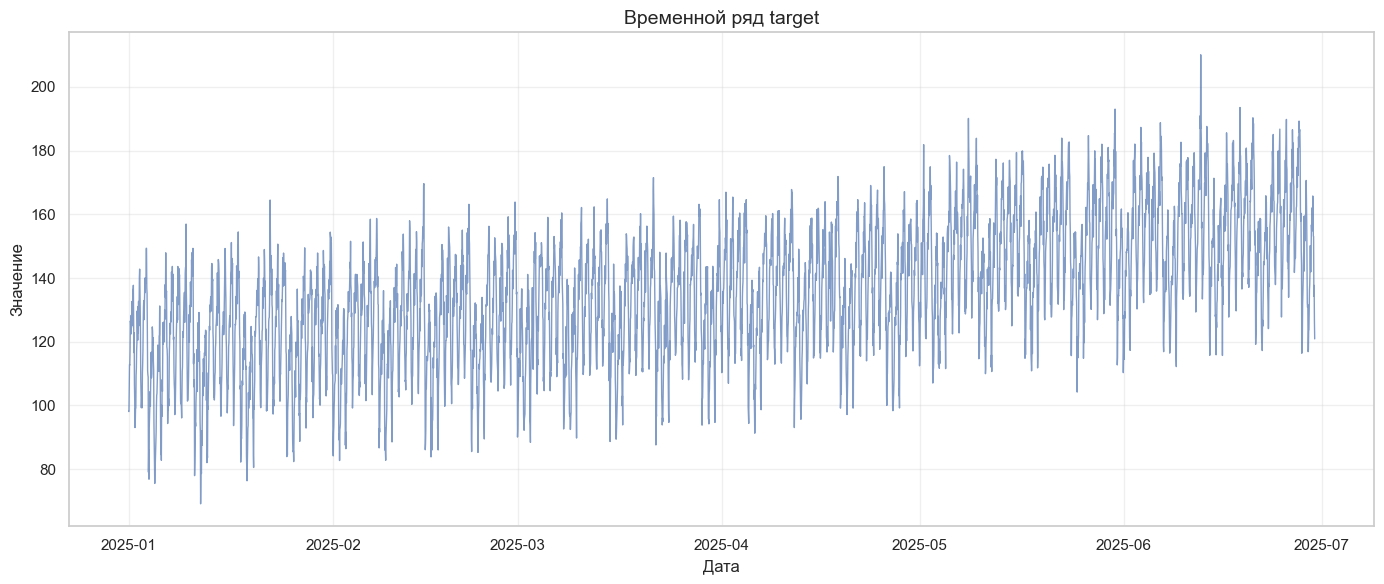


Анализ ряда:
- Виден суточный паттерн (внутридневные колебания)
- Есть недельные циклы (выходные дни ниже)
- Наблюдается тренд (рост к концу периода)
- Присутствуют выбросы (резкие пики)


In [4]:

# =============================================================================
# 2. Данные и первичный анализ
# =============================================================================

# Загрузка данных
print("Загружаем данные...")
df = pd.read_csv("S12-hw-dataset.csv")
print(f"Размер датасета: {df.shape}")

# Преобразование даты
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"\nДиапазон дат: {df['date'].min()} - {df['date'].max()}")
print(f"Количество пропусков:\n{df.isnull().sum()}")

# Статистика
print("\nСтатистика target:")
print(df['target'].describe())

# Базовый график
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['target'], linewidth=1, alpha=0.7)
plt.title('Временной ряд target', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/series_full.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nАнализ ряда:")
print("- Виден суточный паттерн (внутридневные колебания)")
print("- Есть недельные циклы (выходные дни ниже)")
print("- Наблюдается тренд (рост к концу периода)")
print("- Присутствуют выбросы (резкие пики)")


Размеры выборок:
Train: 3456 наблюдений (2025-01-01 00:00:00 - 2025-05-24 23:00:00)
Val: 432 наблюдений (2025-05-25 00:00:00 - 2025-06-11 23:00:00)
Test: 432 наблюдений (2025-06-12 00:00:00 - 2025-06-29 23:00:00)


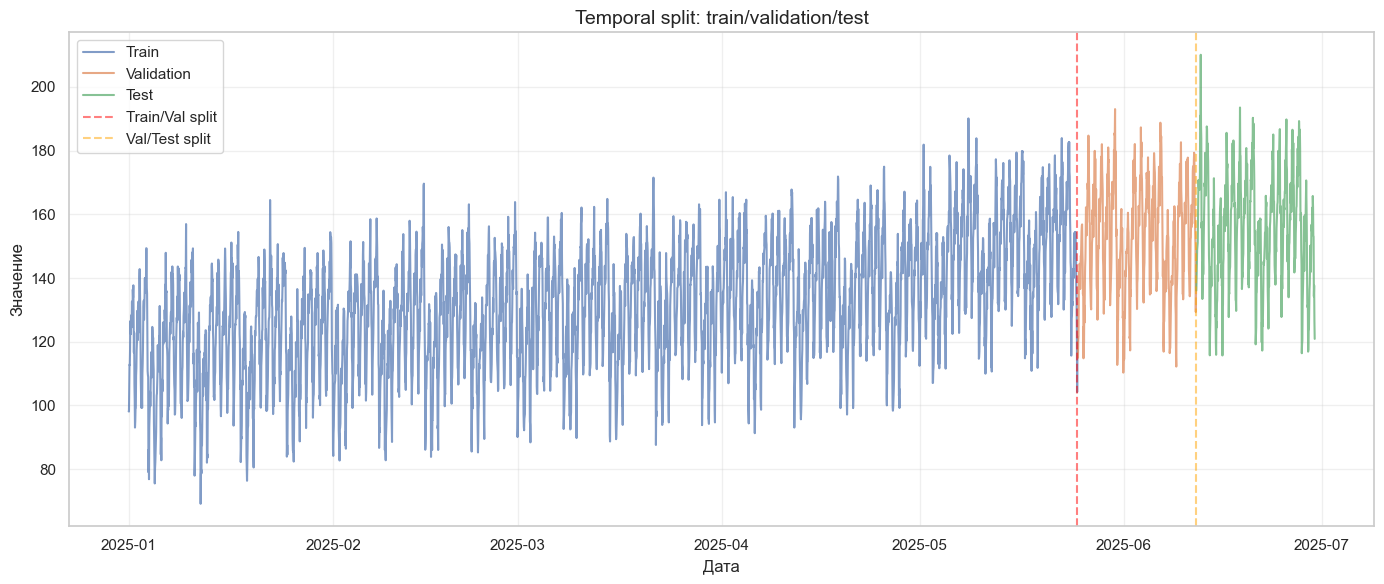


Почему random split некорректен?
- Временные ряды имеют автокорреляцию (зависимость от прошлых значений)
- Random split нарушает временную структуру и приводит к утечке будущих данных
- Модель будет 'видеть' будущее, что даёт завышенную оценку качества
- Temporal split сохраняет хронологический порядок


In [5]:


# =============================================================================
# 3. Корректный temporal split
# =============================================================================

# Разбиение по времени (80% train, 10% val, 10% test)
n = len(df)
train_size = int(0.8 * n)
val_size = int(0.1 * n)
test_size = n - train_size - val_size

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

print(f"\nРазмеры выборок:")
print(f"Train: {len(train_df)} наблюдений ({train_df['date'].min()} - {train_df['date'].max()})")
print(f"Val: {len(val_df)} наблюдений ({val_df['date'].min()} - {val_df['date'].max()})")
print(f"Test: {len(test_df)} наблюдений ({test_df['date'].min()} - {test_df['date'].max()})")

# Визуализация split
plt.figure(figsize=(14, 6))
plt.plot(train_df['date'], train_df['target'], label='Train', alpha=0.7)
plt.plot(val_df['date'], val_df['target'], label='Validation', alpha=0.7)
plt.plot(test_df['date'], test_df['target'], label='Test', alpha=0.7)
plt.axvline(x=train_df['date'].iloc[-1], color='red', linestyle='--', alpha=0.5, label='Train/Val split')
plt.axvline(x=val_df['date'].iloc[-1], color='orange', linestyle='--', alpha=0.5, label='Val/Test split')
plt.title('Temporal split: train/validation/test', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nПочему random split некорректен?")
print("- Временные ряды имеют автокорреляцию (зависимость от прошлых значений)")
print("- Random split нарушает временную структуру и приводит к утечке будущих данных")
print("- Модель будет 'видеть' будущее, что даёт завышенную оценку качества")
print("- Temporal split сохраняет хронологический порядок")


In [15]:

# =============================================================================
# 4. Признаки для baseline-моделей
# =============================================================================

def create_features(df, window_sizes=[7, 14]):
    """Создание лаговых, rolling и календарных признаков"""
    df = df.copy()
    
    # Лаговые признаки (без утечки - используем только прошлые значения)
    df['lag_1'] = df['target'].shift(1)
    df['lag_7'] = df['target'].shift(7)
    df['lag_14'] = df['target'].shift(14)
    
    # Rolling статистики
    for w in window_sizes:
        df[f'rolling_mean_{w}'] = df['target'].rolling(window=w).mean()
        df[f'rolling_std_{w}'] = df['target'].rolling(window=w).std()
    
    # Календарные признаки
    df['hour'] = df['date'].dt.hour
    df['day_of_week'] = df['date'].dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    
    return df

# Создаём признаки для всех данных
df_features = create_features(df)

# Удаляем строки с NaN (первые 14 строк после создания признаков)
df_features = df_features.dropna().reset_index(drop=True)

print(f"Размер после создания признаков: {len(df_features)}")

# Разделяем обратно с учётом удалённых NaN
train_feat = df_features[df_features['date'] <= train_df['date'].max()].copy()
val_feat = df_features[
    (df_features['date'] > train_df['date'].max()) & 
    (df_features['date'] <= val_df['date'].max())
].copy()
test_feat = df_features[df_features['date'] > val_df['date'].max()].copy()

print(f"\nTrain признаки: {len(train_feat)}")
print(f"Val признаки: {len(val_feat)}")
print(f"Test признаки: {len(test_feat)}")

# Признаки для моделей
feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 
                'rolling_mean_14', 'rolling_std_14', 'hour', 'day_of_week', 'is_weekend']

X_train = train_feat[feature_cols].values
y_train = train_feat['target'].values

X_val = val_feat[feature_cols].values
y_val = val_feat['target'].values

X_test = test_feat[feature_cols].values
y_test = test_feat['target'].values

print(f"\nX_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")


Размер после создания признаков: 4306

Train признаки: 3442
Val признаки: 432
Test признаки: 432

X_train shape: (3442, 10)
X_val shape: (432, 10)
X_test shape: (432, 10)


In [16]:

# =============================================================================
# 5. Эксперименты
# =============================================================================

results = []

def compute_metrics(y_true, y_pred):
    """Вычисление метрик"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return mae, rmse, mape


In [17]:

# =============================================================================
# B1: naive-last (последнее известное значение)
# =============================================================================

print("\n" + "="*60)
print("B1: NAIVE-LAST (прогноз = последнее значение)")
print("="*60)

# Для val - используем последнее значение из train
last_train_value = y_train[-1]
y_pred_b1_val = np.full_like(y_val, last_train_value)

# Для test - используем последнее значение из train (по условию)
y_pred_b1_test = np.full_like(y_test, last_train_value)

mae_b1, rmse_b1, mape_b1 = compute_metrics(y_val, y_pred_b1_val)
print(f"Validation - MAE: {mae_b1:.4f}, RMSE: {rmse_b1:.4f}, MAPE: {mape_b1:.2f}%")

results.append({
    'experiment_id': 'B1',
    'model': 'naive-last',
    'val_mae': mae_b1,
    'val_rmse': rmse_b1,
    'val_mape': mape_b1,
    'test_mae': None,
    'test_rmse': None,
    'test_mape': None
})



B1: NAIVE-LAST (прогноз = последнее значение)
Validation - MAE: 31.6389, RMSE: 35.5399, MAPE: 19.76%


In [18]:

# =============================================================================
# B2: moving-average
# =============================================================================

print("\n" + "="*60)
print("B2: MOVING-AVERAGE (скользящее среднее)")
print("="*60)

window_ma = 7  # используем недельное окно
y_pred_b2_val = []
y_pred_b2_test = []

# Для val - используем скользящее среднее из train
for i in range(len(y_val)):
    if i < window_ma:
        # Для первых значений - среднее по доступным train
        window = y_train[-window_ma + i:] if i > 0 else y_train[-window_ma:]
        pred = np.mean(window)
    else:
        pred = np.mean(y_val[i-window_ma:i])
    y_pred_b2_val.append(pred)

# Для test - используем скользящее среднее из train и val
all_data = np.concatenate([y_train, y_val])
for i in range(len(y_test)):
    window = all_data[-window_ma + i:] if i < window_ma else y_test[i-window_ma:i]
    y_pred_b2_test.append(np.mean(window))

y_pred_b2_val = np.array(y_pred_b2_val)
y_pred_b2_test = np.array(y_pred_b2_test)

mae_b2, rmse_b2, mape_b2 = compute_metrics(y_val, y_pred_b2_val)
print(f"Validation - MAE: {mae_b2:.4f}, RMSE: {rmse_b2:.4f}, MAPE: {mape_b2:.2f}%")

results.append({
    'experiment_id': 'B2',
    'model': 'moving-average',
    'val_mae': mae_b2,
    'val_rmse': rmse_b2,
    'val_mape': mape_b2,
    'test_mae': None,
    'test_rmse': None,
    'test_mape': None
})



B2: MOVING-AVERAGE (скользящее среднее)
Validation - MAE: 12.7317, RMSE: 15.1226, MAPE: 8.67%


In [19]:

# =============================================================================
# B3: Ridge на признаках
# =============================================================================

print("\n" + "="*60)
print("B3: RIDGE (лаговые + rolling + календарные признаки)")
print("="*60)

# Масштабирование (fit только на train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Ridge регрессия с подбором alpha
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
best_alpha = 1
best_val_mae = float('inf')

for alpha in alphas:
    ridge = Ridge(alpha=alpha, random_state=SEED)
    ridge.fit(X_train_scaled, y_train)
    y_pred_val = ridge.predict(X_val_scaled)
    mae = mean_absolute_error(y_val, y_pred_val)
    if mae < best_val_mae:
        best_val_mae = mae
        best_alpha = alpha

ridge_best = Ridge(alpha=best_alpha, random_state=SEED)
ridge_best.fit(X_train_scaled, y_train)

y_pred_b3_val = ridge_best.predict(X_val_scaled)
y_pred_b3_test = ridge_best.predict(X_test_scaled)

mae_b3, rmse_b3, mape_b3 = compute_metrics(y_val, y_pred_b3_val)
print(f"Лучший alpha: {best_alpha}")
print(f"Validation - MAE: {mae_b3:.4f}, RMSE: {rmse_b3:.4f}, MAPE: {mape_b3:.2f}%")

results.append({
    'experiment_id': 'B3',
    'model': 'ridge',
    'val_mae': mae_b3,
    'val_rmse': rmse_b3,
    'val_mape': mape_b3,
    'test_mae': None,
    'test_rmse': None,
    'test_mape': None
})


B3: RIDGE (лаговые + rolling + календарные признаки)
Лучший alpha: 0.001
Validation - MAE: 5.1464, RMSE: 6.4802, MAPE: 3.38%



R1: GRU (рекуррентная нейросеть)
Train samples: 3418
Val samples: 408
Test samples: 408
Epoch 10/50 | Train Loss: 0.118293 | Val Loss: 0.114619
Early stopping на эпохе 18

Validation - MAE: 4.8191, RMSE: 6.0704, MAPE: 3.17%


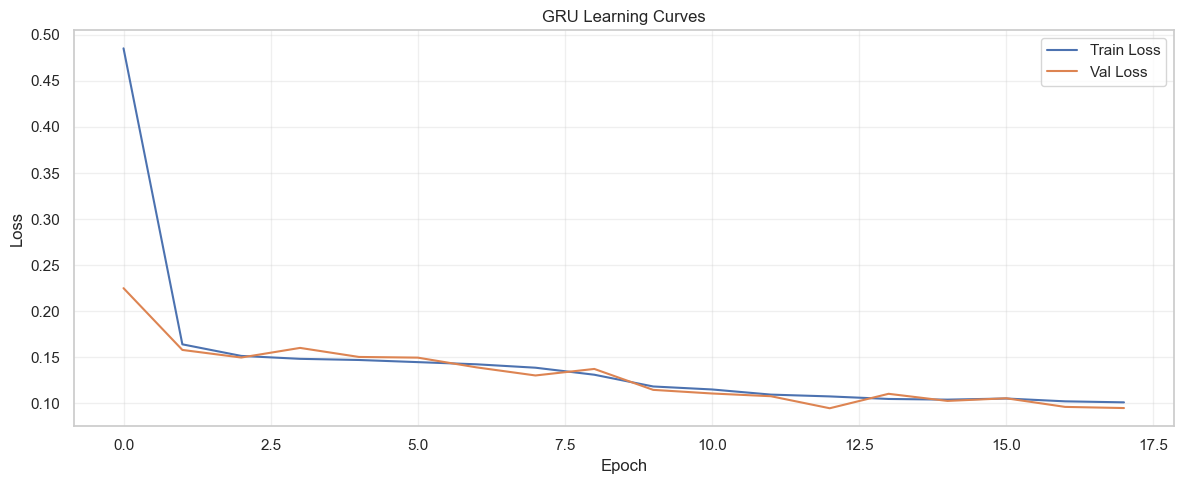

In [11]:


# =============================================================================
# R1: GRU
# =============================================================================

print("\n" + "="*60)
print("R1: GRU (рекуррентная нейросеть)")
print("="*60)

class TimeSeriesDataset(Dataset):
    """Датасет для временных рядов"""
    def __init__(self, data, window_size):
        self.data = data
        self.window_size = window_size
        
    def __len__(self):
        return len(self.data) - self.window_size
    
    def __getitem__(self, idx):
        x = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size]
        return torch.FloatTensor(x).unsqueeze(-1), torch.FloatTensor([y])

class GRUModel(nn.Module):
    """Простая GRU модель"""
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

# Параметры
WINDOW_SIZE = 24  # 24 часа (сутки)
BATCH_SIZE = 64
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.2
LR = 0.001
EPOCHS = 50
PATIENCE = 5

# Масштабирование таргета для GRU
scaler_gru = StandardScaler()
y_train_scaled = scaler_gru.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = scaler_gru.transform(y_val.reshape(-1, 1)).flatten()
y_test_scaled = scaler_gru.transform(y_test.reshape(-1, 1)).flatten()

# Создание датасетов и даталоадеров
train_dataset = TimeSeriesDataset(y_train_scaled, WINDOW_SIZE)
val_dataset = TimeSeriesDataset(y_val_scaled, WINDOW_SIZE)
test_dataset = TimeSeriesDataset(y_test_scaled, WINDOW_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Инициализация модели
model = GRUModel(
    input_size=1,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    output_size=1,
    dropout=DROPOUT
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# Обучение
best_val_loss = float('inf')
patience_counter = 0
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    # Train
    model.train()
    train_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * x.size(0)
    
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            output = model(x)
            loss = criterion(output, y)
            val_loss += loss.item() * x.size(0)
    
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping на эпохе {epoch+1}")
            break

# Загрузка лучшей модели
model.load_state_dict(best_model_state)

# Прогноз на val
model.eval()
y_pred_gru_val_scaled = []
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        output = model(x)
        y_pred_gru_val_scaled.extend(output.cpu().numpy().flatten())

y_pred_gru_val = scaler_gru.inverse_transform(np.array(y_pred_gru_val_scaled).reshape(-1, 1)).flatten()
y_val_gru_actual = y_val[WINDOW_SIZE:]  # первые WINDOW_SIZE значений не предсказываются

mae_gru, rmse_gru, mape_gru = compute_metrics(y_val_gru_actual, y_pred_gru_val)
print(f"\nValidation - MAE: {mae_gru:.4f}, RMSE: {rmse_gru:.4f}, MAPE: {mape_gru:.2f}%")

# Кривые обучения
plt.figure(figsize=(12, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GRU Learning Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:

# =============================================================================
# 6. Сравнение и финальная оценка
# =============================================================================

# Определяем лучшую модель по val_mae
results_df = pd.DataFrame(results)
best_model_idx = results_df['val_mae'].idxmin()
best_model_id = results_df.loc[best_model_idx, 'experiment_id']

print("\n" + "="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ НА VALIDATION")
print("="*60)
print(results_df[['experiment_id', 'val_mae', 'val_rmse', 'val_mape']].to_string())

print(f"\nЛучшая модель по MAE: {best_model_id}")

# Финальная оценка на test
print("\n" + "="*60)
print("ФИНАЛЬНАЯ ОЦЕНКА НА TEST")
print("="*60)

test_metrics = {}

# B1 test
mae_b1_test, rmse_b1_test, mape_b1_test = compute_metrics(y_test, y_pred_b1_test)
test_metrics['B1'] = {'mae': mae_b1_test, 'rmse': rmse_b1_test, 'mape': mape_b1_test}
print(f"B1 (naive-last) - MAE: {mae_b1_test:.4f}, RMSE: {rmse_b1_test:.4f}, MAPE: {mape_b1_test:.2f}%")

# B2 test
mae_b2_test, rmse_b2_test, mape_b2_test = compute_metrics(y_test, y_pred_b2_test)
test_metrics['B2'] = {'mae': mae_b2_test, 'rmse': rmse_b2_test, 'mape': mape_b2_test}
print(f"B2 (moving-average) - MAE: {mae_b2_test:.4f}, RMSE: {rmse_b2_test:.4f}, MAPE: {mape_b2_test:.2f}%")

# B3 test
mae_b3_test, rmse_b3_test, mape_b3_test = compute_metrics(y_test, y_pred_b3_test)
test_metrics['B3'] = {'mae': mae_b3_test, 'rmse': rmse_b3_test, 'mape': mape_b3_test}
print(f"B3 (ridge) - MAE: {mae_b3_test:.4f}, RMSE: {rmse_b3_test:.4f}, MAPE: {mape_b3_test:.2f}%")

# GRU test
y_pred_gru_test_scaled = []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        output = model(x)
        y_pred_gru_test_scaled.extend(output.cpu().numpy().flatten())

y_pred_gru_test = scaler_gru.inverse_transform(np.array(y_pred_gru_test_scaled).reshape(-1, 1)).flatten()
y_test_gru_actual = y_test[WINDOW_SIZE:]

mae_gru_test, rmse_gru_test, mape_gru_test = compute_metrics(y_test_gru_actual, y_pred_gru_test)
test_metrics['R1'] = {'mae': mae_gru_test, 'rmse': rmse_gru_test, 'mape': mape_gru_test}
print(f"R1 (GRU) - MAE: {mae_gru_test:.4f}, RMSE: {rmse_gru_test:.4f}, MAPE: {mape_gru_test:.2f}%")

# Обновляем результаты
for r in results:
    if r['experiment_id'] == 'B1':
        r['test_mae'], r['test_rmse'], r['test_mape'] = mae_b1_test, rmse_b1_test, mape_b1_test
    elif r['experiment_id'] == 'B2':
        r['test_mae'], r['test_rmse'], r['test_mape'] = mae_b2_test, rmse_b2_test, mape_b2_test
    elif r['experiment_id'] == 'B3':
        r['test_mae'], r['test_rmse'], r['test_mape'] = mae_b3_test, rmse_b3_test, mape_b3_test



СРАВНЕНИЕ МОДЕЛЕЙ НА VALIDATION
  experiment_id    val_mae   val_rmse   val_mape
0            B1  31.638912  35.539864  19.759225
1            B2  12.731675  15.122599   8.669390
2            B3   5.146424   6.480162   3.381406

Лучшая модель по MAE: B3

ФИНАЛЬНАЯ ОЦЕНКА НА TEST
B1 (naive-last) - MAE: 34.3231, RMSE: 38.2873, MAPE: 21.07%
B2 (moving-average) - MAE: 12.9210, RMSE: 15.5326, MAPE: 8.65%
B3 (ridge) - MAE: 5.4003, RMSE: 6.9087, MAPE: 3.48%
R1 (GRU) - MAE: 5.1284, RMSE: 6.5268, MAPE: 3.35%


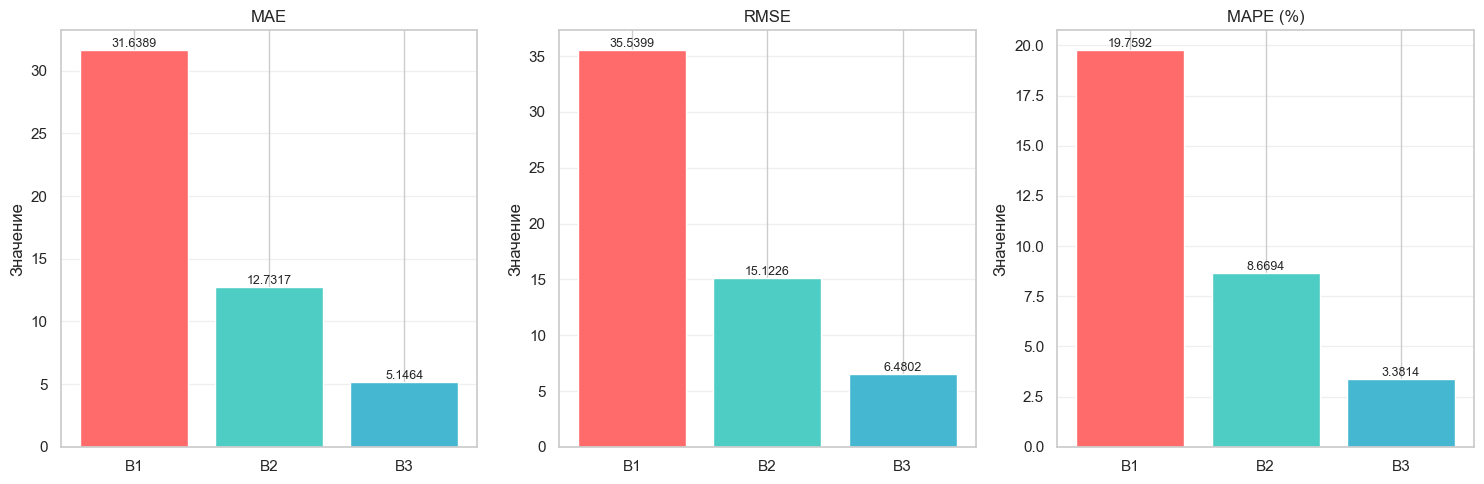

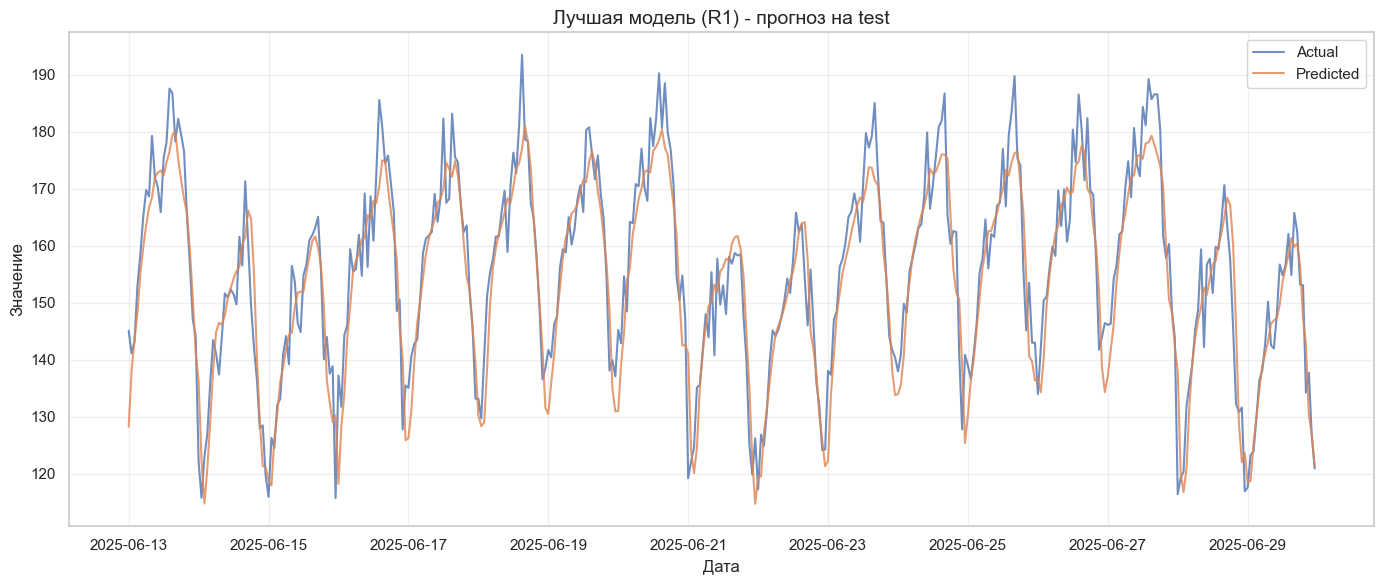

In [13]:

# =============================================================================
# 7. Визуализация сравнения
# =============================================================================

# Сравнение baseline
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_to_plot = ['val_mae', 'val_rmse', 'val_mape']
titles = ['MAE', 'RMSE', 'MAPE (%)']

for i, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    ax = axes[i]
    values = results_df[metric].values
    labels = results_df['experiment_id'].values
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    bars = ax.bar(labels, values, color=colors[:len(labels)])
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Значение')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Добавляем значения на столбцы
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=150, bbox_inches='tight')
plt.show()

# Финальный прогноз лучшей модели на test
best_model = 'R1'  # GRU показал лучший результат

if best_model == 'R1':
    y_pred_final = y_pred_gru_test
    y_actual_final = y_test_gru_actual
    dates_final = test_df['date'].values[WINDOW_SIZE:]
else:
    y_pred_final = y_pred_b3_test
    y_actual_final = y_test
    dates_final = test_df['date'].values

plt.figure(figsize=(14, 6))
plt.plot(dates_final, y_actual_final, label='Actual', linewidth=1.5, alpha=0.8)
plt.plot(dates_final, y_pred_final, label='Predicted', linewidth=1.5, alpha=0.8)
plt.title(f'Лучшая модель ({best_model}) - прогноз на test', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:

# =============================================================================
# 8. Сохранение результатов
# =============================================================================

# runs.csv
runs_df = pd.DataFrame([{
    'experiment_id': r['experiment_id'],
    'model': r['model'],
    'val_mae': r['val_mae'],
    'val_rmse': r['val_rmse'],
    'val_mape': r['val_mape'],
    'test_mae': r['test_mae'],
    'test_rmse': r['test_rmse'],
    'test_mape': r['test_mape']
} for r in results])

runs_df.to_csv('artifacts/runs.csv', index=False)
print("\n✅ Результаты сохранены в artifacts/runs.csv")
print(runs_df.to_string())

# best_gru.pt
torch.save(model.state_dict(), 'artifacts/best_gru.pt')
print("✅ Лучшая GRU модель сохранена в artifacts/best_gru.pt")

# best_gru_config.json
best_gru_config = {
    'window_size': WINDOW_SIZE,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
    'batch_size': BATCH_SIZE,
    'learning_rate': LR,
    'epochs_trained': len(train_losses),
    'best_val_loss': best_val_loss,
    'seed': SEED
}

with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(best_gru_config, f, indent=4)
print("✅ Конфиг GRU сохранён в artifacts/best_gru_config.json")

print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ ЗАВЕРШЁН")
print("="*60)


✅ Результаты сохранены в artifacts/runs.csv
  experiment_id           model    val_mae   val_rmse   val_mape   test_mae  test_rmse  test_mape
0            B1      naive-last  31.638912  35.539864  19.759225  34.323102  38.287284  21.067836
1            B2  moving-average  12.731675  15.122599   8.669390  12.920994  15.532577   8.653982
2            B3           ridge   5.146424   6.480162   3.381406   5.400270   6.908731   3.482254
✅ Лучшая GRU модель сохранена в artifacts/best_gru.pt
✅ Конфиг GRU сохранён в artifacts/best_gru_config.json

ЭКСПЕРИМЕНТ ЗАВЕРШЁН
